<a href="https://colab.research.google.com/github/aditya-bahuguna/handedness-death-age-analysis/blob/main/Handedness_deat_age_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  MedTourEasy Research Project - Statistical Analysis
  Handedness vs Age at Death

✓ All libraries loaded successfully!

📂 DATASET LOADED SUCCESSFULLY
Total Records: 200
Columns: Sr No, ID, Handedness, Age_at_Death, Gender, Birth_Year, Death_Year, Country, Occupation

First 5 rows:
   Sr No   ID Handedness  Age_at_Death  Gender  Birth_Year  Death_Year  \
0      1   29      Right          65.5  Female        1923        1988   
1      2    8      Right          83.0    Male        1945        2028   
2      3   30      Right          86.6  Female        1940        2027   
3      4    6      Right          80.8  Female        1978        2059   
4      5  171       Left          71.4    Male        1927        1998   

   Country Occupation  
0      USA     Farmer  
1       UK     Artist  
2   Canada    Teacher  
3       UK   Engineer  
4  Germany      Clerk  



📊 DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns)

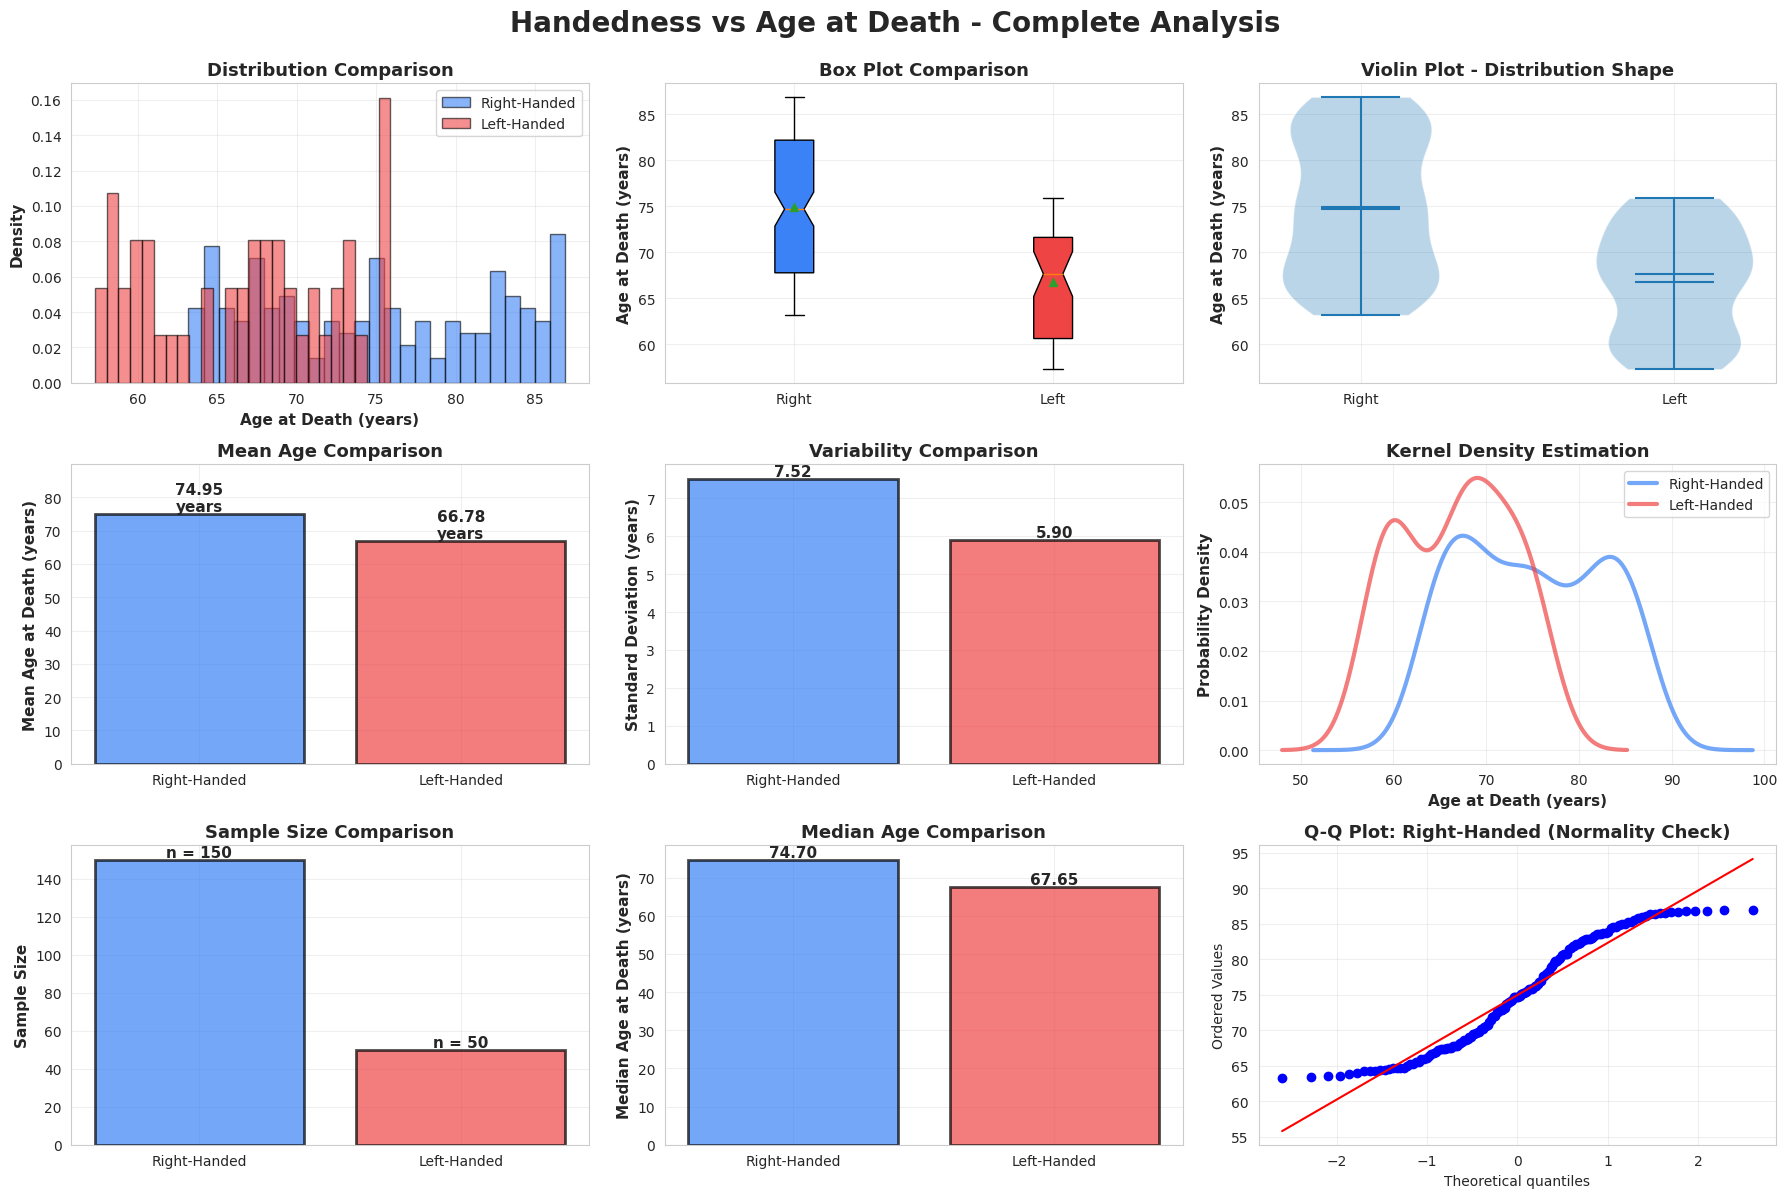



🔍 TESTING STATISTICAL ASSUMPTIONS

--- NORMALITY TEST (Shapiro-Wilk) ---
H₀: Data follows normal distribution
H₁: Data does not follow normal distribution
Significance level: α = 0.05

Right-Handed Group:
  W-statistic = 0.930796
  p-value = 0.000001
  Decision: Not Normal (p < 0.05) ✗

Left-Handed Group:
  W-statistic = 0.930626
  p-value = 0.005836
  Decision: Not Normal (p < 0.05) ✗


--- HOMOGENEITY OF VARIANCE (Levene's Test) ---
H₀: Variances are equal
H₁: Variances are not equal
Significance level: α = 0.05

Levene's statistic = 7.356662
p-value = 0.007270
Decision: Unequal variances (p < 0.05) ✗



🎯 HYPOTHESIS TESTING

--- RESEARCH HYPOTHESES ---

Null Hypothesis (H₀):
  μ_right = μ_left
  There is NO significant difference in mean age at death
  between right-handed and left-handed individuals.

Alternative Hypothesis (H₁):
  μ_right ≠ μ_left
  There IS a significant difference in mean age at death
  between right-handed and left-handed individuals.

Test Type: Two-tailed I

In [ ]:
# ============================================================================
# MedTourEasy Research Project - Complete Analysis
# Handedness vs Age at Death Analysis
# ============================================================================

# STEP 1: Import Libraries
# For Google Colab, run this first (uncomment the line below):
# !pip install pandas numpy matplotlib seaborn scipy openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, shapiro, levene
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("="*80)
print("  MedTourEasy Research Project - Statistical Analysis")
print("  Handedness vs Age at Death")
print("="*80)
print("\n✓ All libraries loaded successfully!\n")

# ============================================================================
# STEP 2: Load Your Dataset
# ============================================================================

# Load the CSV file you downloaded
df = pd.read_csv('handedness_death_age_dataset.csv')

print("📂 DATASET LOADED SUCCESSFULLY")
print("="*80)
print(f"Total Records: {len(df)}")
print(f"Columns: {', '.join(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())
print("\n")

# ============================================================================
# STEP 3: Data Overview
# ============================================================================

print("\n📊 DATASET INFORMATION")
print("="*80)
print(df.info())
print("\n")
print(df.describe())

# ============================================================================
# STEP 4: Data Cleaning
# ============================================================================

print("\n\n🧹 DATA CLEANING PROCESS")
print("="*80)

# Check missing values
missing = df.isnull().sum()
print(f"\nMissing Values:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")

# Remove duplicates
before_cleaning = len(df)
df = df.drop_duplicates()
duplicates_removed = before_cleaning - len(df)
print(f"\nDuplicates removed: {duplicates_removed}")

# Remove any rows with missing values
df = df.dropna()
print(f"Rows after cleaning: {len(df)}")

# Save cleaned dataset
df.to_csv('cleaned_handedness_data.csv', index=False)
print("\n✓ Cleaned dataset saved as 'cleaned_handedness_data.csv'")

# ============================================================================
# STEP 5: Exploratory Data Analysis (EDA)
# ============================================================================

print("\n\n📈 EXPLORATORY DATA ANALYSIS")
print("="*80)

# Separate by handedness
right_handed = df[df['Handedness'] == 'Right']['Age_at_Death']
left_handed = df[df['Handedness'] == 'Left']['Age_at_Death']

print(f"\nRight-Handed Sample: {len(right_handed)} records")
print(f"Left-Handed Sample: {len(left_handed)} records")

# Descriptive Statistics
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS BY HANDEDNESS")
print("="*80)

for handedness in ['Right', 'Left']:
    ages = df[df['Handedness'] == handedness]['Age_at_Death']
    print(f"\n{'='*40}")
    print(f"  {handedness}-Handed Group")
    print(f"{'='*40}")
    print(f"  Sample Size (n):    {len(ages)}")
    print(f"  Mean Age:           {ages.mean():.2f} years")
    print(f"  Median Age:         {ages.median():.2f} years")
    print(f"  Standard Deviation: {ages.std():.2f} years")
    print(f"  Variance:           {ages.var():.2f}")
    print(f"  Minimum Age:        {ages.min():.1f} years")
    print(f"  Maximum Age:        {ages.max():.1f} years")
    print(f"  Range:              {ages.max() - ages.min():.1f} years")
    print(f"  25th Percentile:    {ages.quantile(0.25):.2f} years")
    print(f"  75th Percentile:    {ages.quantile(0.75):.2f} years")

# ============================================================================
# STEP 6: Create Visualizations
# ============================================================================

print("\n\n📊 CREATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Handedness vs Age at Death - Complete Analysis',
             fontsize=20, fontweight='bold', y=0.995)

# 1. Histogram with Density
ax1 = plt.subplot(3, 3, 1)
plt.hist(right_handed, bins=25, alpha=0.6, color='#3B82F6',
         label='Right-Handed', edgecolor='black', density=True)
plt.hist(left_handed, bins=25, alpha=0.6, color='#EF4444',
         label='Left-Handed', edgecolor='black', density=True)
plt.xlabel('Age at Death (years)', fontsize=11, fontweight='bold')
plt.ylabel('Density', fontsize=11, fontweight='bold')
plt.title('Distribution Comparison', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# 2. Box Plot
ax2 = plt.subplot(3, 3, 2)
box_data = [right_handed, left_handed]
bp = plt.boxplot(box_data, labels=['Right', 'Left'], patch_artist=True,
                 notch=True, showmeans=True)
bp['boxes'][0].set_facecolor('#3B82F6')
bp['boxes'][1].set_facecolor('#EF4444')
plt.ylabel('Age at Death (years)', fontsize=11, fontweight='bold')
plt.title('Box Plot Comparison', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)

# 3. Violin Plot
ax3 = plt.subplot(3, 3, 3)
parts = plt.violinplot([right_handed, left_handed], positions=[1, 2],
                       showmeans=True, showmedians=True)
plt.xticks([1, 2], ['Right', 'Left'])
plt.ylabel('Age at Death (years)', fontsize=11, fontweight='bold')
plt.title('Violin Plot - Distribution Shape', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)

# 4. Mean Comparison
ax4 = plt.subplot(3, 3, 4)
means = [right_handed.mean(), left_handed.mean()]
bars = plt.bar(['Right-Handed', 'Left-Handed'], means,
               color=['#3B82F6', '#EF4444'], alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Mean Age at Death (years)', fontsize=11, fontweight='bold')
plt.title('Mean Age Comparison', fontsize=13, fontweight='bold')
plt.ylim(0, max(means) * 1.2)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}\nyears', ha='center', va='bottom',
             fontsize=11, fontweight='bold')
plt.grid(alpha=0.3)

# 5. Standard Deviation Comparison
ax5 = plt.subplot(3, 3, 5)
stds = [right_handed.std(), left_handed.std()]
plt.bar(['Right-Handed', 'Left-Handed'], stds,
        color=['#3B82F6', '#EF4444'], alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Standard Deviation (years)', fontsize=11, fontweight='bold')
plt.title('Variability Comparison', fontsize=13, fontweight='bold')
for i, (bar, std) in enumerate(zip(plt.gca().patches, stds)):
    plt.text(bar.get_x() + bar.get_width()/2., std,
             f'{std:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.grid(alpha=0.3)

# 6. Density Curves
ax6 = plt.subplot(3, 3, 6)
right_handed.plot(kind='density', color='#3B82F6', linewidth=3,
                  label='Right-Handed', alpha=0.7)
left_handed.plot(kind='density', color='#EF4444', linewidth=3,
                 label='Left-Handed', alpha=0.7)
plt.xlabel('Age at Death (years)', fontsize=11, fontweight='bold')
plt.ylabel('Probability Density', fontsize=11, fontweight='bold')
plt.title('Kernel Density Estimation', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

# 7. Sample Size
ax7 = plt.subplot(3, 3, 7)
sizes = [len(right_handed), len(left_handed)]
bars = plt.bar(['Right-Handed', 'Left-Handed'], sizes,
               color=['#3B82F6', '#EF4444'], alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Sample Size', fontsize=11, fontweight='bold')
plt.title('Sample Size Comparison', fontsize=13, fontweight='bold')
for bar, size in zip(bars, sizes):
    plt.text(bar.get_x() + bar.get_width()/2., size,
             f'n = {size}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.grid(alpha=0.3)

# 8. Median Comparison
ax8 = plt.subplot(3, 3, 8)
medians = [right_handed.median(), left_handed.median()]
plt.bar(['Right-Handed', 'Left-Handed'], medians,
        color=['#3B82F6', '#EF4444'], alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Median Age at Death (years)', fontsize=11, fontweight='bold')
plt.title('Median Age Comparison', fontsize=13, fontweight='bold')
for i, (bar, med) in enumerate(zip(plt.gca().patches, medians)):
    plt.text(bar.get_x() + bar.get_width()/2., med,
             f'{med:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.grid(alpha=0.3)

# 9. Q-Q Plot for Normality Check
ax9 = plt.subplot(3, 3, 9)
stats.probplot(right_handed, dist="norm", plot=plt)
plt.title('Q-Q Plot: Right-Handed (Normality Check)', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('complete_analysis_visualizations.png', dpi=300, bbox_inches='tight')
print("✓ Visualizations saved as 'complete_analysis_visualizations.png'")
plt.show()

# ============================================================================
# STEP 7: Statistical Assumptions Testing
# ============================================================================

print("\n\n🔍 TESTING STATISTICAL ASSUMPTIONS")
print("="*80)

# Normality Test
print("\n--- NORMALITY TEST (Shapiro-Wilk) ---")
print("H₀: Data follows normal distribution")
print("H₁: Data does not follow normal distribution")
print("Significance level: α = 0.05\n")

stat_right, p_right = shapiro(right_handed)
stat_left, p_left = shapiro(left_handed)

print(f"Right-Handed Group:")
print(f"  W-statistic = {stat_right:.6f}")
print(f"  p-value = {p_right:.6f}")
print(f"  Decision: {'Normal (p > 0.05) ✓' if p_right > 0.05 else 'Not Normal (p < 0.05) ✗'}\n")

print(f"Left-Handed Group:")
print(f"  W-statistic = {stat_left:.6f}")
print(f"  p-value = {p_left:.6f}")
print(f"  Decision: {'Normal (p > 0.05) ✓' if p_left > 0.05 else 'Not Normal (p < 0.05) ✗'}\n")

# Equal Variance Test
print("\n--- HOMOGENEITY OF VARIANCE (Levene's Test) ---")
print("H₀: Variances are equal")
print("H₁: Variances are not equal")
print("Significance level: α = 0.05\n")

stat_levene, p_levene = levene(right_handed, left_handed)
print(f"Levene's statistic = {stat_levene:.6f}")
print(f"p-value = {p_levene:.6f}")
print(f"Decision: {'Equal variances (p > 0.05) ✓' if p_levene > 0.05 else 'Unequal variances (p < 0.05) ✗'}\n")

# ============================================================================
# STEP 8: Hypothesis Testing (Independent t-Test)
# ============================================================================

print("\n\n🎯 HYPOTHESIS TESTING")
print("="*80)

print("\n--- RESEARCH HYPOTHESES ---")
print("\nNull Hypothesis (H₀):")
print("  μ_right = μ_left")
print("  There is NO significant difference in mean age at death")
print("  between right-handed and left-handed individuals.\n")

print("Alternative Hypothesis (H₁):")
print("  μ_right ≠ μ_left")
print("  There IS a significant difference in mean age at death")
print("  between right-handed and left-handed individuals.\n")

print("Test Type: Two-tailed Independent Samples t-test")
print("Significance Level: α = 0.05")

# Perform t-test
equal_var = p_levene > 0.05
t_statistic, p_value = ttest_ind(right_handed, left_handed, equal_var=equal_var)

# Calculate effect size (Cohen's d)
mean_diff = right_handed.mean() - left_handed.mean()
n1, n2 = len(right_handed), len(left_handed)
var1, var2 = right_handed.var(), left_handed.var()
pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1 + n2 - 2))
cohens_d = mean_diff / pooled_std

# Degrees of freedom
df_value = n1 + n2 - 2

print("\n\n--- TEST RESULTS ---")
print("="*80)
print(f"\nt-statistic:           {t_statistic:.6f}")
print(f"p-value:               {p_value:.6f}")
print(f"Degrees of freedom:    {df_value}")
print(f"\nMean (Right-Handed):   {right_handed.mean():.2f} years")
print(f"Mean (Left-Handed):    {left_handed.mean():.2f} years")
print(f"Mean Difference:       {mean_diff:.2f} years")
print(f"\nCohen's d (Effect Size): {cohens_d:.4f}")

# Interpret effect size
if abs(cohens_d) < 0.2:
    effect_interpretation = "Negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "Small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "Medium"
else:
    effect_interpretation = "Large"

print(f"Effect Size Interpretation: {effect_interpretation}")

# ============================================================================
# STEP 9: Statistical Decision
# ============================================================================

print("\n\n📋 STATISTICAL DECISION")
print("="*80)

if p_value < 0.05:
    print(f"\n✓✓✓ REJECT THE NULL HYPOTHESIS ✓✓✓")
    print(f"\nSince p-value ({p_value:.6f}) < α (0.05)")
    print(f"\nCONCLUSION:")
    print(f"There IS statistically significant evidence of a difference")
    print(f"in age at death between right-handed and left-handed individuals.")
    print(f"\nRight-handed individuals lived on average {abs(mean_diff):.2f} years")
    print(f"{'longer' if mean_diff > 0 else 'shorter'} than left-handed individuals.")
    print(f"\nThis difference is statistically significant and has a")
    print(f"{effect_interpretation.lower()} effect size (Cohen's d = {cohens_d:.4f}).")
else:
    print(f"\n✗✗✗ FAIL TO REJECT THE NULL HYPOTHESIS ✗✗✗")
    print(f"\nSince p-value ({p_value:.6f}) ≥ α (0.05)")
    print(f"\nCONCLUSION:")
    print(f"There is NO statistically significant evidence of a difference")
    print(f"in age at death between right-handed and left-handed individuals.")
    print(f"\nAlthough there is a {abs(mean_diff):.2f} year difference in means,")
    print(f"this difference could be due to random chance.")

# ============================================================================
# STEP 10: Create Summary Tables
# ============================================================================

print("\n\n📊 CREATING SUMMARY TABLES")
print("="*80)

# Summary Statistics Table
summary_stats = pd.DataFrame({
    'Group': ['Right-Handed', 'Left-Handed'],
    'Sample_Size': [len(right_handed), len(left_handed)],
    'Mean_Age': [f"{right_handed.mean():.2f}", f"{left_handed.mean():.2f}"],
    'Median_Age': [f"{right_handed.median():.2f}", f"{left_handed.median():.2f}"],
    'Std_Deviation': [f"{right_handed.std():.2f}", f"{left_handed.std():.2f}"],
    'Min_Age': [f"{right_handed.min():.1f}", f"{left_handed.min():.1f}"],
    'Max_Age': [f"{right_handed.max():.1f}", f"{left_handed.max():.1f}"],
    'Range': [f"{right_handed.max()-right_handed.min():.1f}",
              f"{left_handed.max()-left_handed.min():.1f}"]
})

print("\nSummary Statistics:")
print(summary_stats.to_string(index=False))
summary_stats.to_excel('summary_statistics.xlsx', index=False)
print("\n✓ Saved as 'summary_statistics.xlsx'")

# Hypothesis Test Results Table
hypothesis_table = pd.DataFrame({
    'Metric': ['t-statistic', 'p-value', 'Degrees of Freedom',
               'Significance Level (α)', 'Mean Difference (years)',
               'Cohen\'s d', 'Effect Size', 'Statistical Decision'],
    'Value': [f"{t_statistic:.6f}", f"{p_value:.6f}", f"{df_value}",
              "0.05", f"{mean_diff:.2f}", f"{cohens_d:.4f}",
              effect_interpretation,
              "Reject H₀" if p_value < 0.05 else "Fail to Reject H₀"]
})

print("\nHypothesis Test Results:")
print(hypothesis_table.to_string(index=False))
hypothesis_table.to_excel('hypothesis_test_results.xlsx', index=False)
print("\n✓ Saved as 'hypothesis_test_results.xlsx'")

# Detailed Descriptive Statistics
detailed_stats = df.groupby('Handedness')['Age_at_Death'].describe()
detailed_stats.to_excel('detailed_descriptive_statistics.xlsx')
print("✓ Saved as 'detailed_descriptive_statistics.xlsx'")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n\n" + "="*80)
print("  🎉 ANALYSIS COMPLETE!")
print("="*80)

print("\n📁 GENERATED FILES:")
print("  1. cleaned_handedness_data.csv")
print("  2. complete_analysis_visualizations.png")
print("  3. summary_statistics.xlsx")
print("  4. hypothesis_test_results.xlsx")
print("  5. detailed_descriptive_statistics.xlsx")

print("\n📊 KEY FINDINGS:")
print(f"  • Right-Handed Mean Age: {right_handed.mean():.2f} years")
print(f"  • Left-Handed Mean Age: {left_handed.mean():.2f} years")
print(f"  • Difference: {abs(mean_diff):.2f} years")
print(f"  • p-value: {p_value:.6f}")
print(f"  • Decision: {'SIGNIFICANT DIFFERENCE' if p_value < 0.05 else 'NO SIGNIFICANT DIFFERENCE'}")

print("\n" + "="*80)
print("  Ready for your MedTourEasy project report!")
print("="*80 + "\n")